In [175]:
import sys
sys.path.append("../../src/")
from common_imports import *
import kblock_ising_model as kb
import kibble_zurek as kz 

In [ ]:
def g_t(t,tau):
    return 1-t/tau

taus =[1,1000]

In [179]:

tau = taus[0]

t1 = np.linspace(-tau,tau/10,100)

gs = g_t(t1,tau)
###Get the equilibrium hamiltonians at each g 
L = 100
x1 = []
for g in gs:
    k_vals = kb.k_vals(L)

    U = kb.U(k_vals,g)
    x1.append(kb.sigma_general([0,1],U,k_vals))

x1= array(x1)

###Get the exact time dpeendent project at each g(t)
y1 = []
for ti in t1:
    state= kz.state(L,tau,ti)
    y1.append(kz.sigma_general([0,1],state))

y1= array(y1)

In [181]:

tau = taus[1]

t2 = np.linspace(-tau,tau/10,100)

gs = g_t(t2,tau)
###Get the equilibrium hamiltonians at each g 
L = 100
x2 = []
for g in gs:
    k_vals = kb.k_vals(L)

    U = kb.U(k_vals,g)
    x2.append(kb.P_n(2,U,k_vals))

x2= array(x2)

###Get the exact time dpeendent project at each g(t)
y2 = []
for ti in t2:
    state= kz.state(L,tau,ti)
    y2.append(kz.P_n(2,state))

y2= array(y2)

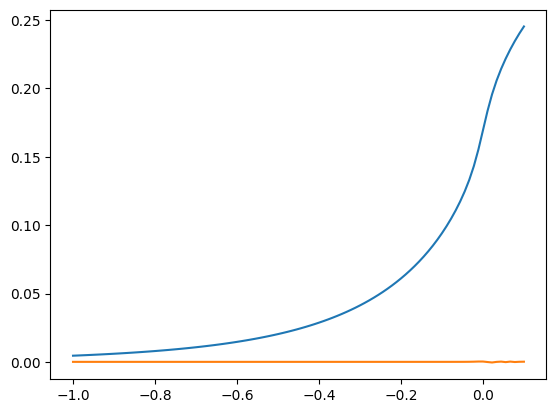

In [189]:

plot(t1/taus[0],x1-y1)
plot(t2/taus[1],(x2-y2))
#loglog()
show()
# plot(t1/taus[0],(x1-y1)*taus[0]**2)

# plot(t2/taus[1],(x2-y2)*taus[1]**2)

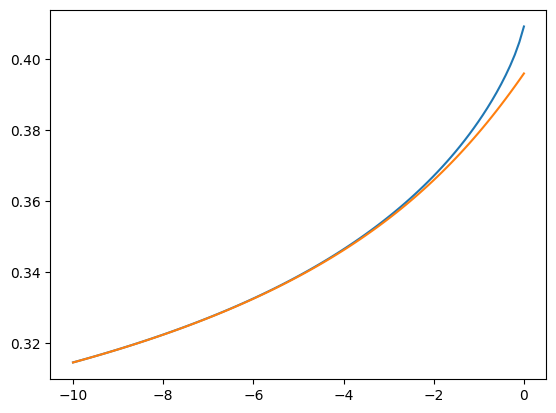

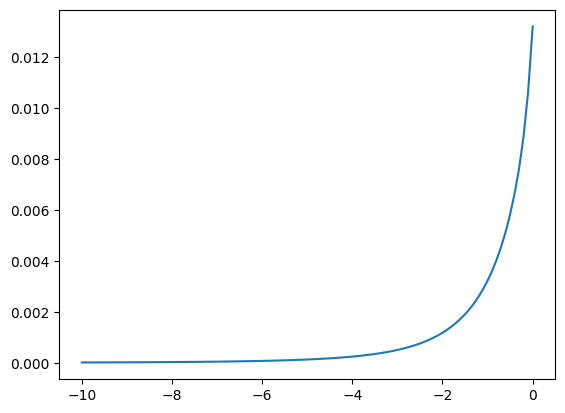

In [32]:
plot(t,x)
plot(t,y)

show()
plot(t,x-y)

In [ ]:
def theta_k(k,g):
    return np.atan2( sin(k), cos(k)-g)

k = np.linspace(-pi,pi,100)
g=1
t = theta_k(k,g)

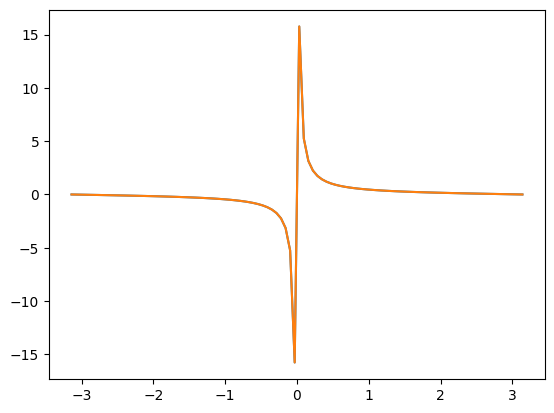

In [74]:
plot(k,sin(t)/2/sqrt(1+g-2*g*cos(k)))
plot(k, sin(k)/2/(1+g*g-2*g*cos(k)))

In [75]:
import numpy as np
from scipy.integrate import quad

# parameters
tau = 100.0
v0 = 1.0 / tau
t0 = -100.0

def g(t):
    return 1.0 - t / tau

g0 = g(t0)

# dispersion
def eps(k):
    return np.sqrt(1 + g0**2 - 2 * g0 * np.cos(k))

# Bogoliubov angle theta_k
def theta_k(k):
    return np.arctan2(np.sin(k), np.cos(k) - g0)

# AGP matrix element sin(k)/(2 eps(k)^2)
def AGP(k):
    return np.sin(k) / (2.0 * eps(k)**2)

# sigma_x sigma_x matrix element
def Omat(k):
    return -np.cos(k) + 1j * np.sin(k - theta_k(k))

# phase
def phase(k, t, tp):
    return np.exp(1j * 2 * eps(k) * (t - tp))

# J(t, tp) = ∫ dk phase * AGP * Omat
def J(t, tp):
    integrand = lambda k: phase(k, t, tp) * AGP(k) * Omat(k)
    # quad integrates real-valued functions; we integrate real and imaginary parts separately
    real_part = quad(lambda k: np.real(integrand(k)), -np.pi, np.pi)[0]
    imag_part = quad(lambda k: np.imag(integrand(k)), -np.pi, np.pi)[0]
    return real_part + 1j*imag_part

# deltaO(t) = -2 v0 ∫ dt' Im[J(t, t')]
def deltaO(t):
    def integrand(tp):
        return np.imag(J(t, tp))
    val = quad(integrand, t0, t)[0]
    return -2.0 * v0 * val


In [ ]:
deltaO(-10)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2389/3618496923.py:38: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  real_part = quad(lambda k: np.real(integrand(k)), -np.pi, np.pi)[0]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2389/3618496923.py:39: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
 

3.412104445039976e-07

In [77]:
import numpy as np

# ----- parameters -----
tau = 100.0
v0  = 1.0/tau
t0  = -100.0

# time resolution
Nt = 2000                           # number of time steps for t'
t_min, t_max = t0, 50.0             # integrate tp from t0 to t
tp_grid = np.linspace(t_min, t_max, Nt)
dt = tp_grid[1] - tp_grid[0]

# k resolution
Nk = 2000
k_grid = np.linspace(-np.pi, np.pi, Nk)
dk = k_grid[1] - k_grid[0]


# ----- define functions evaluated at t0 -----
g0 = 1 - t0/tau

def eps(k):
    return np.sqrt(1 + g0**2 - 2*g0*np.cos(k))

def theta_k(k):
    return np.arctan2(np.sin(k), np.cos(k) - g0)

# AGP element = sin(k)/(2 eps(k)^2)
def AGP(k):
    return np.sin(k) / (2*eps(k)**2)

# sigma_x sigma_{x+1} matrix element
def Omat(k):
    return -np.cos(k) + 1j*np.sin(k - theta_k(k))


# ----- precompute stuff -----
eps_k   = eps(k_grid)
AGP_k   = AGP(k_grid)
Omat_k  = Omat(k_grid)


# ----- J(t, tp) entire double integrand -----
def J_integrand(t, tp):
    phase = np.exp(1j * 2*eps_k*(t - tp))
    return np.sum(phase * AGP_k * Omat_k) * dk   # integral over k


# ----- deltaO(t) using explicit sum over tp -----
def deltaO(t):
    vals = np.array([np.imag(J_integrand(t, tp)) for tp in tp_grid])
    integral_tp = np.sum(vals) * dt
    return -2 * v0 * integral_tp


In [ ]:
ts = np.linspace(-tau,0,100)

x = [deltaO(t) for t in ts]

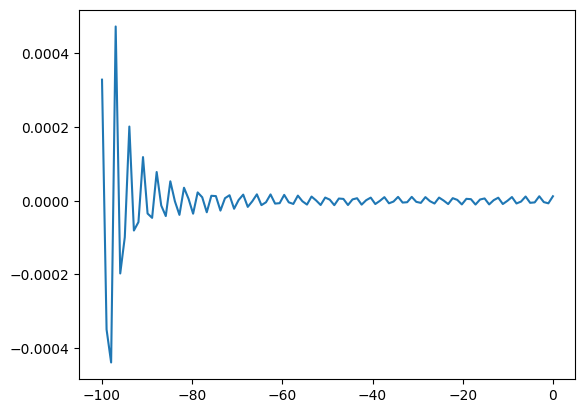

In [80]:
plot(ts,x)

In [121]:
import numpy as np
from tqdm import tqdm
from joblib import Parallel, delayed

# ----------------------------------------
# Parameters
# ----------------------------------------
tau = 500.0
t0  = -10*tau
v0  = 1.0/tau

Nt = 2000
tp_min, tp_max = t0, 0.0
tp_grid = np.linspace(tp_min, tp_max, Nt)
dt = tp_grid[1] - tp_grid[0]

Nk = 2000
k_grid = np.linspace(-np.pi, np.pi, Nk)
dk = k_grid[1] - k_grid[0]


# ----------------------------------------
# Time-dependent quantities
# ----------------------------------------
def g(t):
    return 1 - t/tau

def eps_vec(k_array, t):
    g_t = g(t)
    return np.sqrt(1 + g_t**2 - 2*g_t*np.cos(k_array))

def theta_k_vec(k_array, t):
    g_t = g(t)
    return np.arctan2(np.sin(k_array), np.cos(k_array) - g_t)

def AGP_vec(k_array, t):
    return np.sin(k_array) / (2 * eps_vec(k_array, t)**2)

def Omat_vec(k_array, t):
    return -np.cos(k_array) + 1j*np.sin(k_array - theta_k_vec(k_array, t))


# ----------------------------------------
# Vectorized dynamic phase:
# exp(i ∫_{tp}^{t} 2 eps(k,s) ds ) for entire k-array
# ----------------------------------------
def dynamic_phase_vec(k_array, tp, t):
    Ns = 160
    s_grid = np.linspace(tp, t, Ns)
    eps_grid = eps_vec(k_array[:, None], s_grid[None, :])
    integral = np.trapezoid(2 * eps_grid, s_grid, axis=1)
    return np.exp(1j * integral)


# ----------------------------------------
# J(t, tp) = ∫ dk [phase * AGP * Omat]
# ----------------------------------------
def J_tp(t, tp):
    phase_vals = dynamic_phase_vec(k_grid, tp, t)
    AGP_vals   = AGP_vec(k_grid, tp)
    O_vals     = Omat_vec(k_grid, t)
    return np.sum(phase_vals * AGP_vals * O_vals) * dk


# ----------------------------------------
# Parallel deltaO using joblib
# ----------------------------------------
def deltaO(t, n_jobs=-1):
    results = Parallel(n_jobs=n_jobs)(
        delayed(lambda tp: np.imag(J_tp(t, tp)))(tp)
        for tp in tqdm(tp_grid, desc="Integrating over tp")
    )
    integral_tp = np.sum(results) * dt
    return 2 * v0 * integral_tp


Integrating over tp: 100%|██████████| 2000/2000 [00:00<00:00, 3322.90it/s]


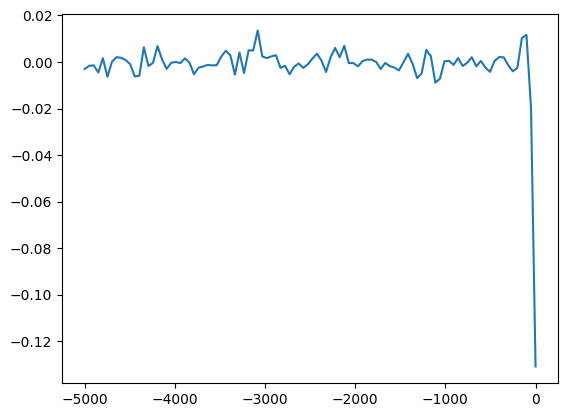

In [122]:
t = np.linspace(-10*tau,0,100)

x = array([deltaO(ti) for ti in t])

plot(t,x)


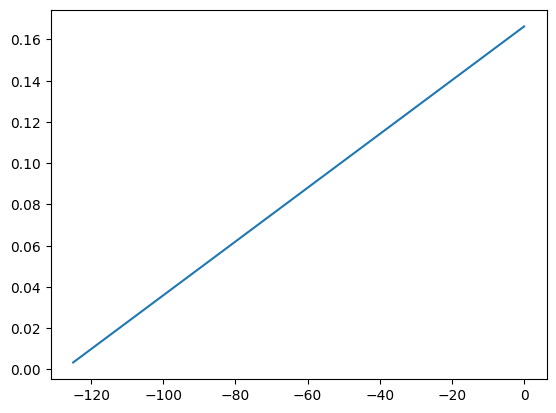

In [112]:
plot(ts,abs(array(x)))

In [192]:
gs

array([2.        , 1.98888889, 1.97777778, 1.96666667, 1.95555556,
       1.94444444, 1.93333333, 1.92222222, 1.91111111, 1.9       ,
       1.88888889, 1.87777778, 1.86666667, 1.85555556, 1.84444444,
       1.83333333, 1.82222222, 1.81111111, 1.8       , 1.78888889,
       1.77777778, 1.76666667, 1.75555556, 1.74444444, 1.73333333,
       1.72222222, 1.71111111, 1.7       , 1.68888889, 1.67777778,
       1.66666667, 1.65555556, 1.64444444, 1.63333333, 1.62222222,
       1.61111111, 1.6       , 1.58888889, 1.57777778, 1.56666667,
       1.55555556, 1.54444444, 1.53333333, 1.52222222, 1.51111111,
       1.5       , 1.48888889, 1.47777778, 1.46666667, 1.45555556,
       1.44444444, 1.43333333, 1.42222222, 1.41111111, 1.4       ,
       1.38888889, 1.37777778, 1.36666667, 1.35555556, 1.34444444,
       1.33333333, 1.32222222, 1.31111111, 1.3       , 1.28888889,
       1.27777778, 1.26666667, 1.25555556, 1.24444444, 1.23333333,
       1.22222222, 1.21111111, 1.2       , 1.18888889, 1.17777

In [197]:
g_t(t,tau)

array([6.        , 5.94949495, 5.8989899 , 5.84848485, 5.7979798 ,
       5.74747475, 5.6969697 , 5.64646465, 5.5959596 , 5.54545455,
       5.49494949, 5.44444444, 5.39393939, 5.34343434, 5.29292929,
       5.24242424, 5.19191919, 5.14141414, 5.09090909, 5.04040404,
       4.98989899, 4.93939394, 4.88888889, 4.83838384, 4.78787879,
       4.73737374, 4.68686869, 4.63636364, 4.58585859, 4.53535354,
       4.48484848, 4.43434343, 4.38383838, 4.33333333, 4.28282828,
       4.23232323, 4.18181818, 4.13131313, 4.08080808, 4.03030303,
       3.97979798, 3.92929293, 3.87878788, 3.82828283, 3.77777778,
       3.72727273, 3.67676768, 3.62626263, 3.57575758, 3.52525253,
       3.47474747, 3.42424242, 3.37373737, 3.32323232, 3.27272727,
       3.22222222, 3.17171717, 3.12121212, 3.07070707, 3.02020202,
       2.96969697, 2.91919192, 2.86868687, 2.81818182, 2.76767677,
       2.71717172, 2.66666667, 2.61616162, 2.56565657, 2.51515152,
       2.46464646, 2.41414141, 2.36363636, 2.31313131, 2.26262

In [330]:
def theta_k(k,g):
    return np.atan2(sin(k),g-cos(k))
y= []
L = 50
tau = 200
t = np.linspace(-tau/2,0,100)
gs = g_t(t,tau)
for g in gs:
    k = np.linspace(-pi,pi,L)
    theta = theta_k(k,g)

    z = 1j*sin(theta)

    xx= -cos(k)+1j*sin(k-theta)
    epsilon_k = sqrt(1+g**2-2*g*cos(k))
    y.append(2/tau*sum((xx*z+np.conjugate(xx*z)/(2*epsilon_k**2)))/L)



In [331]:
x1 = []
for g in tqdm(gs):
    k_vals = kb.k_vals(L)

    U = kb.U(k_vals,g)
    x1.append(kb.sigma_general([0,1],U,k_vals))

x1= array(x1)

###Get the exact time dpeendent project at each g(t)
y1 = []
for ti in tqdm(t):
    state= kz.state(L,tau,ti)
    y1.append(kz.sigma_general([0,1],state))

y1= array(y1)

100%|██████████| 100/100 [00:07<00:00, 13.24it/s]


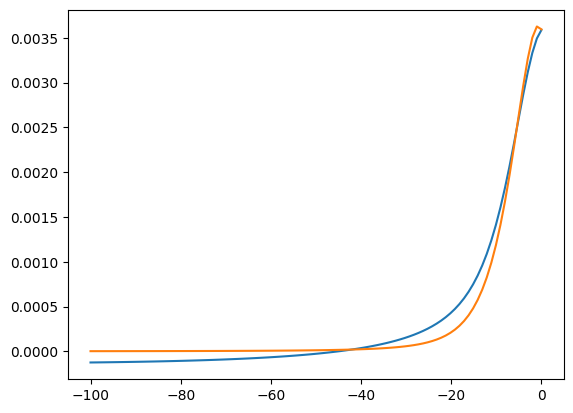

In [336]:
plot(t,(array(y))/5/pi)
#loglog("log")
plot(t,(x1-y1))